# Self-Attention 与 Transformer Block

> 上一节，我们给每个 token 的向量加上了位置信息。至此，输入层的工作完成：每个 token 既有语义信息（"这个词是什么"），也有位置信息（"这个词在第几个位置"）。但这里有一个问题——这些向量是独立计算的，彼此之间没有交流。换句话说，模型此时不知道 token 之间有什么关系。
>
> 这一节从这个问题出发，引入 Attention 机制，让每个 token 能够从上下文中按需提取信息。我们先把 Attention 的计算过程拆开手算一遍，再逐步加入因果遮蔽、多头机制、前馈网络、残差连接和 LayerNorm，最终组装成一个 Transformer Block。

以 "the cat sat on the mat" 为例。如果不看上下文，sat 只是一个表示"坐"的向量。但有了上下文，模型就能知道谁在坐（cat），坐在哪里（mat）。再看 "bank"：在 "river bank" 里指河岸，在 "bank account" 里指银行——四个字母完全相同，含义由周围的词决定。

这些例子指向一个核心需求：token 之间需要交换信息。Transformer 的整体结构因此分为三段：

```
输入层：Tokenizer → Embedding → Position Encoding    ← 前三节已完成
核心层：N 个 Transformer Block                        ← 本节重点
输出层：Linear → logits                               ← 下一节
```

本节要搭建的是中间的 Transformer Block。Block 的核心机制叫 Attention——让每个 token 先判断上下文中谁更相关，再按相关程度加权混合信息。具体来说，我们会按以下顺序逐步搭建：

1. **Scaled Dot-Product Attention**：用 Q、K、V 三个向量算出注意力权重，再加权混合——这是最核心的计算
2. **Causal Mask**：遮住未来位置，让 GPT 只能看前面的 token
3. **Multi-Head Attention**：多组 Q/K/V 并行工作，从不同角度提取上下文信息
4. **Transformer Block**：把 Multi-Head Attention 和前馈网络（FFN）组装在一起，加上残差连接和 LayerNorm

每一步只在前一步的基础上加一个新组件，最后拼成完整的 Block。

## 本节要点

通过这一节的学习，以下问题应该能够回答：

1. Attention 在解决什么问题？
2. Q、K、V 分别代表什么？
3. Scaled Dot-Product Attention 的四步计算是什么？
4. GPT 为什么需要 Causal Mask？
5. Multi-Head Attention 和 Transformer Block 是怎样组装起来的？

## 1. Attention 的直觉

Attention 的输出可以用一组权重来描述。假设模型处理 "the cat sat on the mat"，当它处理 sat 时，可能给出的关注比例是：

```
      the  cat  sat  on  the  mat
sat: 0.05 0.35 0.10 0.05 0.05 0.40
```

这些数字加起来等于 1。cat 和 mat 权重大，说明 sat 会从它们那里读入更多信息。最终得到的 sat 新向量，就融合了"猫坐在垫子上"这个上下文。

计算这些关注比例是 Attention 要解决的核心问题。它引入三个向量——Q（Query）、K（Key）、V（Value），分别扮演"提问"、"贴标签"和"提供内容"三个角色：

- Q（Query）：我想找什么？比如 sat 在问："谁在做这个动作？动作发生在哪里？"
- K（Key）：我是什么标签？比如 cat 的 Key 可能让别人看出："我是一个动作的发出者。"
- V（Value）：我能提供什么内容？如果 cat 被关注，真正被混合进输出的是它的 Value。

一个简单的类比是查资料：Query 是想查的问题，Key 是每份资料的标题或标签，Value 是资料正文。先用 Query 和 Key 判断哪份资料相关，再把相关资料的 Value 按比例读进来。

在 Self-Attention 中，Q、K、V 都从同一个输入矩阵 X 计算而来，只是乘了三套不同的权重矩阵：

```
Q = X @ W_Q
K = X @ W_K
V = X @ W_V
```

同一份输入经过三种不同的线性投影，变成了三种角色。下面用代码把 X 构造出来，再一步步手算 Attention。

In [1]:
# === 词表 → 句子 → Token IDs → Embedding 查表 → X ===
import torch
import torch.nn as nn
_ = torch.manual_seed(42)
vocab = {"the": 0, "a": 1, "cat": 2, "dog": 3, "sat": 4,
         "ran": 5, "on": 6, "mat": 7, "[PAD]": 8, "[UNK]": 9}
vocab_size = len(vocab)
id2word = {v: k for k, v in vocab.items()}

# 句子 → token ids
sentence = ["the", "cat", "sat"]
token_ids = [vocab[w] for w in sentence]  # [0, 2, 4]

# token ids → Embedding 查表 → X
d_model = 4
embedding = nn.Embedding(vocab_size, d_model)
token_ids_tensor = torch.tensor(token_ids)  # [3]
X = embedding(token_ids_tensor)             # [3, 4]

print(f"词表大小: {vocab_size}, 句子: {' '.join(sentence)}")
print(f"Token IDs: {token_ids}")
print(f"X 形状: {list(X.shape)}  ← [seq_len=3, d_model=4]")
print(f"\nX = (来自 Embedding 查表，不是 randn):\n{X}")
print(f"\n解释: X[0]='the' → {X[0].tolist()}")
print(f"      X[1]='cat' → {X[1].tolist()}")
print(f"      X[2]='sat' → {X[2].tolist()}")

词表大小: 10, 句子: the cat sat
Token IDs: [0, 2, 4]
X 形状: [3, 4]  ← [seq_len=3, d_model=4]

X = (来自 Embedding 查表，不是 randn):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [ 1.6423, -0.1596, -0.4974,  0.4396]], grad_fn=<EmbeddingBackward0>)

解释: X[0]='the' → [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
      X[1]='cat' → [-0.7521352767944336, 1.6487230062484741, -0.3924786448478699, -1.4036071300506592]
      X[2]='sat' → [1.6423169374465942, -0.1595974713563919, -0.4973975419998169, 0.439589262008667]


In [2]:
# === 从上一步的 X 出发，计算 Q/K/V ===
import torch.nn as nn
seq_len = X.shape[0]  # = 3
d_k = 4

# Q/K/V 都来自 X，但各自乘不同的权重矩阵（用 nn.Linear，和后面 MHA 一致）
W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

Q = W_Q(X)  # [3, 4] — 每个 token 的「查询」
K = W_K(X)  # [3, 4] — 每个 token 的「标签」
V = W_V(X)  # [3, 4] — 每个 token 的「内容」

print(f"X 形状: {X.shape}  →  Q/K/V 形状: {Q.shape}")
print(f"→ Q、K、V 都来自同一个 X，乘了不同的矩阵")


X 形状: torch.Size([3, 4])  →  Q/K/V 形状: torch.Size([3, 4])
→ Q、K、V 都来自同一个 X，乘了不同的矩阵


## 2. Scaled Dot-Product Attention

Attention 的计算分四步。第一步是用 Q 和 K 算相关度分数——第 i 行、第 j 列表示 token i 对 token j 有多感兴趣，点积越大匹配越强。

In [3]:
# Step 1: 注意力分数 = Q × K^T
# 第 i 行第 j 列 = token i 对 token j 的原始相关度
attention_scores = Q @ K.T  # [3, 4] @ [4, 3] = [3, 3]

print(f"注意力分数矩阵 {list(attention_scores.shape)} = [{seq_len}×{seq_len}]:")
print(attention_scores)
print(f"\n第 i 行 = token {list(range(seq_len))} 对各 token 的分数")

注意力分数矩阵 [3, 3] = [3×3]:
tensor([[-0.9139, -0.6422,  0.4003],
        [-0.4184, -0.0361,  0.2776],
        [-0.8690,  0.0373, -0.1415]], grad_fn=<MmBackward0>)

第 i 行 = token [0, 1, 2] 对各 token 的分数


**缩放**

点积结果可能很大。数值太大时，softmax 会变得过于自信，训练不稳定。

所以要除以 `√d_k`，让分数更稳。

为什么是 √d_k，而不是别的数？可以从方差的角度理解。假设 Q 和 K 的每个元素都是独立随机变量，均值为 0、方差为 1。那么 $q_i k_i$ 的方差也是 1，点积 $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ 的方差就是 $d_k$。

也就是说，维度越高，点积的绝对值通常越大。当 $d_k = 64$ 时，点积的典型量级大约在 8 附近（$\sqrt{64} = 8$），而 softmax 输入在 ±8 这个范围内已经接近饱和，梯度会非常小。

除以 $\sqrt{d_k}$ 相当于把点积的方差拉回 1，让 softmax 工作在梯度充足的区间。

In [4]:
# Step 2: 缩放 / √d_k  → 防止 d_k 大时点积过大，softmax 梯度消失
import math
d_k = Q.shape[-1]
scaled_scores = attention_scores / math.sqrt(d_k)

print(f"缩放因子: √{d_k} = {math.sqrt(d_k):.2f}")
print(f"缩放前 token 0: {attention_scores[0].tolist()}")
print(f"缩放后 token 0: {scaled_scores[0].tolist()}  ← 值变小，相对大小不变")

缩放因子: √4 = 2.00
缩放前 token 0: [-0.9139026999473572, -0.642159104347229, 0.4002934694290161]
缩放后 token 0: [-0.4569513499736786, -0.3210795521736145, 0.20014673471450806]  ← 值变小，相对大小不变


第三步，softmax 把一行分数变成概率——每一行加起来等于 1，表示这个 token 对其他 token 的关注比例。

第四步，用这些权重去混合 V。谁权重大，谁的信息就进来得多。这样每个 token 的输出就融合了它关注到的上下文。

In [5]:
# Step 3: Softmax → 把分数变成概率（每行加起来 = 1）
import torch.nn.functional as F
attention_weights = F.softmax(scaled_scores, dim=-1)

print(f"注意力权重矩阵 {list(attention_weights.shape)}:")
print(attention_weights)

# 验证每行和为 1
print(f"\n每行和: {attention_weights.sum(dim=-1).tolist()}  ← 都是 1.0")

注意力权重矩阵 [3, 3]:
tensor([[0.2454, 0.2811, 0.4735],
        [0.2757, 0.3338, 0.3905],
        [0.2493, 0.3921, 0.3586]], grad_fn=<SoftmaxBackward0>)

每行和: [1.0, 1.0, 0.9999998807907104]  ← 都是 1.0


In [6]:
# Step 4: 加权求和 — 用注意力权重混合 V
output = attention_weights @ V  # [3, 3] @ [3, 4] = [3, 4]

print(f"输出形状: {list(output.shape)} = [{seq_len}, {d_model}]")
print(f"\n输入  token 0: {X[0].tolist()}")
print(f"输出 token 0: {output[0].tolist()}")
print(f"→ 不一样！因为 token 0 按权重融合了 token 1、2 的信息")

输出形状: [3, 4] = [3, 4]

输入  token 0: [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232]
输出 token 0: [-0.07093444466590881, 0.7985435128211975, 0.7109794616699219, 0.05999895930290222]
→ 不一样！因为 token 0 按权重融合了 token 1、2 的信息


### 四步总结

**Step 1 — 线性投影生成 Q/K/V：**

$$Q = XW_Q, \quad K = XW_K, \quad V = XW_V$$

同一份输入 $X$ 乘三套不同权重，得到"提问""标签""内容"三个角色。

**Step 2 — 算相关度分数：**

$$S = QK^\top$$

第 $i$ 行第 $j$ 列是 token $i$ 对 token $j$ 的原始匹配分数，点积越大表示越相关。

**Step 3 — 缩放 + Softmax：**

$$A = \text{softmax}\!\left(\frac{S}{\sqrt{d_k}}\right)$$

除以 $\sqrt{d_k}$ 防止点积过大导致 softmax 饱和。Softmax 之后每行加起来等于 1，得到一组注意力权重。

**Step 4 — 加权求和：**

$$\text{output} = AV$$

谁的权重大，谁的信息就进来得多。每个 token 的输出向量融合了它关注到的上下文。

合并成一条公式：

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

## 3. 因果遮蔽

上一节实现的 Scaled Dot-Product Attention 里，每个 token 可以看到序列中的所有 token，包括自己后面的。在理解整句话的语义时这没有问题。但 GPT 是生成模型，它的工作方式是**一个字一个字往后写**。训练时也是这个逻辑：给它一句话，让它练习"看到前面的词，猜下一个词"。

### GPT 为什么要练习"猜下一个词"

先退一步想：GPT 最终要做什么？给它一段开头，它接着往后写。比如输入 "从前有座山，山里有座"，它应该接着写 "庙"。也就是说，GPT 的全部能力可以归结为一件事：**给定已经写好的文字，判断下一个词最可能是什么**。

如果它总是能猜对下一个词，就能一直写下去，写出连贯的长文。那怎么练出这个能力？就像学写作文：老师给你一句话的开头 "春天来了，冰雪"，让你填下一个词。你填 "融化"，对了；填 "消融"，也对；填 "键盘"，就不太对。通过大量这样的练习，你逐渐学会了什么样的上文之后应该跟什么样的词。

GPT 的训练完全一样。给它一句话 "the cat sat on the mat"，让它反复练习：

```
看到 "the"              → 猜下一个词（答案是 cat）
看到 "the cat"          → 猜下一个词（答案是 sat）
看到 "the cat sat"      → 猜下一个词（答案是 on）
看到 "the cat sat on"    → 猜下一个词（答案是 the）
看到 "the cat sat on the" → 猜下一个词（答案是 mat）
```

一句话就能练 5 次。训练数据里有几十亿句话，每句话都这样拆成很多个"看前文、猜后文"的练习题。练得多了，模型就学会了：the 后面通常跟名词，cat sat 后面通常跟介词，on 后面通常跟 the……

### 问题：Attention 让每个 token 都能看到所有 token

这些猜词任务是**同时**完成的。模型把 6 个 token 一起送进去，一次前向传播算出 6 个输出向量，每个输出向量各自拿去猜自己位置的下一个词。

回忆 Scaled Dot-Product Attention 的计算。第一步算出分数矩阵 $S = QK^\top$。对于 3 个 token（the, cat, sat），这个矩阵是 $3 \times 3$ 的：

```
         the   cat   sat
the:    [0.2,  0.3,  0.1]
cat:    [0.3,  0.5,  0.8]
sat:    [0.1,  0.2,  0.6]
```

每一行代表一个 token 对其他 token 的关注度。第 1 行是 cat 的关注度：cat 对 the 是 0.3，对自己是 0.5，对 sat 是 0.8。经过 softmax 之后，这些分数变成权重（加起来等于 1），cat 的输出向量就是 the、cat、sat 三个 token 的 Value 按权重混合的结果。

但训练目标是让 cat 的输出向量去预测下一个词——而下一个词正好就是 sat。cat 的注意力权重里 sat 占了最大比例，相当于 cat 的输出里混入了大量 sat 的信息。模型拿这个输出去预测"下一个词是什么"，当然很容易猜到 sat。但模型并没有学会从 the 推出 cat，它只是直接看到了答案。

打个比方：考试时题目是"the \_\_\_ sat"，答案填 cat。如果允许偷看后面一个词，你只要看到 sat 就知道前面大概率是主语 cat——分数好看，但换一道偷看不到答案的题就不会做了。

### 遮蔽：让每个 token 只能看到自己和前面

解决思路很直接：既然问题是 token 看到了后面的答案，那就把它后面的分数全部遮掉。

token 0（the）应该只看 the，因为它要猜的下一个词在位置 1，不能看到位置 1 和 2 的信息。

token 1（cat）应该只看 the 和 cat，因为它要猜的下一个词在位置 2，不能看到位置 2 的信息。

token 2（sat）可以看所有，因为它要猜的下一个词在位置 3，而位置 0-2 都是"前面"，没有泄露。

把"谁能看谁"画成矩阵，1 表示允许看，0 表示遮住：

```
         the  cat  sat
the:    [ 1,   0,   0 ]    ← 第 0 行：只有位置 0 是 1
cat:    [ 1,   1,   0 ]    ← 第 1 行：位置 0、1 是 1
sat:    [ 1,   1,   1 ]    ← 第 2 行：全部是 1
```

这个矩阵恰好是一个下三角矩阵——对角线以上全是 0。

### 遮蔽具体怎么作用在分数上

把这个遮蔽应用到原始分数矩阵上，遮住的位置用 $-\infty$ 替换：

```
原始分数:                 遮蔽后:
[0.2, 0.3, 0.1]  →  [0.2,  -∞,  -∞ ]   ← the 的行：遮掉 cat 和 sat
[0.3, 0.5, 0.8]  →  [0.3,  0.5, -∞ ]   ← cat 的行：遮掉 sat
[0.1, 0.2, 0.6]  →  [0.1,  0.2, 0.6]   ← sat 的行：不遮
```

然后对每一行做 softmax。softmax 的性质是：输入 $-\infty$ 的位置输出 0。遮住的位置在权重里完全消失：

```
遮蔽后:                    softmax 权重:
[0.2,  -∞,  -∞ ]  →  [1.00, 0.00, 0.00]   ← the 100% 只用自己
[0.3,  0.5, -∞ ]  →  [0.45, 0.55, 0.00]   ← cat 用 the(45%)和自己(55%)，sat 权重=0
[0.1,  0.2, 0.6]  →  [0.22, 0.27, 0.51]   ← sat 看到所有
```

cat 这一行里 sat 的权重变成了 0。cat 的输出向量只包含 the 和 cat 自身的信息，完全不包含 sat。模型拿这个输出去预测下一个词，就必须真的学会从 the 推出 cat，不能再靠偷看。

用代码实现这个遮蔽，只需要生成一个下三角矩阵。

In [7]:
# 用第 2 节的 scaled_scores，实际走一遍遮蔽 + softmax 的完整流程
import torch
import torch.nn.functional as F

# 第 2 节算出的缩放分数
print("=== Step 1: 第 2 节算出的缩放分数（无遮蔽）===")
print(f"scaled_scores:\n{scaled_scores.detach()}\n")

# 生成 causal mask（下三角矩阵）
seq_len = scaled_scores.shape[0]
mask = torch.tril(torch.ones(seq_len, seq_len))
print(f"=== Step 2: Causal Mask ({seq_len}×{seq_len}) ===")
print(f"mask (1=允许看, 0=遮住):\n{mask.int()}\n")

# 把 mask=0 的位置填 -inf
masked_scores = scaled_scores.masked_fill(mask == 0, float('-inf'))
print(f"=== Step 3: 遮蔽后的分数 ===")
print(f"把 0 的位置替换为 -inf:\n{masked_scores.detach()}\n")

# softmax
masked_weights = F.softmax(masked_scores, dim=-1)
print(f"=== Step 4: 遮蔽后 softmax ===")
print(f"遮蔽后的权重:\n{masked_weights.detach()}\n")

# 对比：无遮蔽 vs 有遮蔽
unmasked_weights = F.softmax(scaled_scores, dim=-1)
print(f"=== 对比：遮蔽前后的权重 ===")
print(f"{'':>8} {'无遮蔽':>30}  {'有遮蔽':>30}")
labels = ['the', 'cat', 'sat']
for i in range(seq_len):
    row_before = [f"{v:.3f}" for v in unmasked_weights[i].tolist()]
    row_after = [f"{v:.3f}" for v in masked_weights[i].tolist()]
    print(f"{labels[i]:>8} {str(row_before):>30}  {str(row_after):>30}")

print()
print("关键观察：")
print(f"  无遮蔽时 cat 对 sat 的权重 = {unmasked_weights[1,2]:.3f}（偷看了答案）")
print(f"  有遮蔽时 cat 对 sat 的权重 = {masked_weights[1,2]:.3f}（完全遮住）")
print(f"  cat 的注意力只分配给 the 和 cat 自身")

=== Step 1: 第 2 节算出的缩放分数（无遮蔽）===
scaled_scores:
tensor([[-0.4570, -0.3211,  0.2001],
        [-0.2092, -0.0181,  0.1388],
        [-0.4345,  0.0186, -0.0708]])

=== Step 2: Causal Mask (3×3) ===
mask (1=允许看, 0=遮住):
tensor([[1, 0, 0],
        [1, 1, 0],
        [1, 1, 1]], dtype=torch.int32)

=== Step 3: 遮蔽后的分数 ===
把 0 的位置替换为 -inf:
tensor([[-0.4570,    -inf,    -inf],
        [-0.2092, -0.0181,    -inf],
        [-0.4345,  0.0186, -0.0708]])

=== Step 4: 遮蔽后 softmax ===
遮蔽后的权重:
tensor([[1.0000, 0.0000, 0.0000],
        [0.4524, 0.5476, 0.0000],
        [0.2493, 0.3921, 0.3586]])

=== 对比：遮蔽前后的权重 ===
                                    无遮蔽                             有遮蔽
     the    ['0.245', '0.281', '0.473']     ['1.000', '0.000', '0.000']
     cat    ['0.276', '0.334', '0.390']     ['0.452', '0.548', '0.000']
     sat    ['0.249', '0.392', '0.359']     ['0.249', '0.392', '0.359']

关键观察：
  无遮蔽时 cat 对 sat 的权重 = 0.390（偷看了答案）
  有遮蔽时 cat 对 sat 的权重 = 0.000（完全遮住）
  cat 的注意力只分配给 the 和 cat 自身


## 4. 多头注意力

### 什么是"头"

回顾第 2 节的代码。我们定义了三个线性变换 `W_Q`、`W_K`、`W_V`（都是 `nn.Linear(d_model, d_k)`），用它们把输入 $X$ 投影成 Q/K/V，算一次 Attention，输出一个 $3 \times 3$ 的权重矩阵：

```python
W_Q = nn.Linear(d_model, d_k, bias=False)   # 第 2 节的代码
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)
Q = W_Q(X)   # [3, 4]
K = W_K(X)   # [3, 4]
V = W_V(X)   # [3, 4]
# → scores → softmax → weights → output
```

这里出现了两个维度。`d_model` 是模型内部统一的向量维度——Embedding 输出是 `d_model` 维，Transformer Block 的输入输出也是 `d_model` 维，整个模型从头到尾都保持这个宽度。不同框架给这个维度起了不同的名字：

| 名称 | 来源 | 示例 |
|:---|:---|:---|
| `d_model` | Transformer 原始论文、PyTorch `nn.Transformer` | 论文中 $d_{model} = 512$ |
| `embed_dim` | PyTorch `nn.MultiheadAttention` | `embed_dim=768` |
| `hidden_size` | HuggingFace Transformers（BERT、LLaMA 等） | `hidden_size=4096` |
| `n_embd` | OpenAI GPT 系列的配置文件 | `n_embd=768` |

四个名字指的是同一个东西：token 向量的维度。`d_k` 是 Q/K/V 投影后的维度。第 2 节里 `d_model = d_k = 4`，所以两者相同。但在多头注意力里它们会不同，后面会看到。

这一组 `W_Q, W_K, W_V` 加上后续的 Attention 计算，就是一个"头"。在代码里，一个头就是三行 `nn.Linear` 加上四步 Attention 计算。

算出来的权重矩阵长这样：

```
         the   cat   sat
the:    [0.25, 0.28, 0.47]
cat:    [0.28, 0.33, 0.39]
sat:    [0.25, 0.39, 0.36]
```

每一行是一个 token 对所有 token 的关注比例，加起来等于 1。用这组权重去混合 V，得到每个 token 的新向量。

说它是"单头"，是因为只有一组 `W_Q, W_K, W_V`，每个 token 只能得到一组权重。sat 对 the 的关注度是 0.25，对 cat 是 0.39，对自己是 0.36——只有这一组数字，所有关注点被压缩在一起。

### 为什么需要多个头

单头的问题是：注意力权重只有一组，必须把所有关注点压缩到同一组概率里。以 "the cat sat on the mat" 为例，当模型处理 sat 时，它既要关注谁在做动作（cat），又要关注动作发生在哪里（mat），还可能关注时态（on 前面的 sat 是过去式）。这些关注点性质不同，但单头注意力只能给出一个综合的权重分配，就好比老师让你给一道菜打分，但只能给一个总分——味道 90 分，价格 60 分，综合起来给 75 分，信息就丢了。

如果让两个人分别回答，一个专评味道，一个专评性价比，信息就更丰富。多头注意力做的就是这件事：给每个 token 分配多组权重，每组权重可以关注不同的东西。

### 多头在代码里怎么实现

最直白的想法是：既然要 2 个头，就定义 2 组独立的 `W_Q, W_K, W_V`，各自算各自的 Attention：

```python
# 直白的写法：2 个头，各定义一组线性变换
# 头 1
W_Q_1 = nn.Linear(d_model, d_k, bias=False)   # 8 → 4
W_K_1 = nn.Linear(d_model, d_k, bias=False)
W_V_1 = nn.Linear(d_model, d_k, bias=False)

# 头 2
W_Q_2 = nn.Linear(d_model, d_k, bias=False)   # 8 → 4
W_K_2 = nn.Linear(d_model, d_k, bias=False)
W_V_2 = nn.Linear(d_model, d_k, bias=False)

# 各自算 Attention
Q_1 = W_Q_1(x)   # [batch, seq_len, 4]
K_1 = W_K_1(x)   # [batch, seq_len, 4]
V_1 = W_V_1(x)   # [batch, seq_len, 4]
# → 头 1 的 scores → softmax → output_1

Q_2 = W_Q_2(x)   # [batch, seq_len, 4]
K_2 = W_K_2(x)   # [batch, seq_len, 4]
V_2 = W_V_2(x)   # [batch, seq_len, 4]
# → 头 2 的 scores → softmax → output_2

# 拼在一起
output = cat(output_1, output_2)  # [batch, seq_len, 8]
```

这里 `d_model = 8`，每个头的 `d_k = 4`。三者的关系是 `d_k = d_model / num_heads`，或者说 `d_model = num_heads × d_k`。`d_model` 是整个模型的统一维度，输入输出都是 8 维；`d_k` 是每个头内部的维度，只在单个头的计算中存在，最后把 `num_heads` 个头的 `d_k` 维输出拼回来，恢复成 `d_model`。

这种写法逻辑清楚，但有个实际问题：GPT-3 有 96 个头，难道要写 96 组 `W_Q, W_K, W_V`？实际实现中，PyTorch 把多组的参数合并成一个大矩阵，用一次矩阵乘法同时算完所有头的投影，然后用 `view + transpose` 把结果拆开：

```python
# 实际写法：一个大矩阵，一次算完，再拆
W_Q = nn.Linear(d_model, d_model, bias=False)   # 8 → 8（不是 8 → 4）
Q = W_Q(x)                                       # [batch, seq_len, 8]

# 把 8 维拆成 2 个头 × 4 维
num_heads = 2
d_k = d_model // num_heads                       # 8 // 2 = 4
Q = Q.view(batch, seq_len, num_heads, d_k).transpose(1, 2)
# → [batch, 2, seq_len, 4]
```

`d_k = d_model // num_heads` 就是刚才那个关系：8 维被分成 2 组，每组 4 维。`view + transpose` 只是把连续的内存重新解释成"2 个头、每个头 4 维"的形状，不涉及任何计算。这一步做的事情和上面"直白写法"完全等价：一个 `nn.Linear(8, 8)` 内部包含的参数量，等于两个 `nn.Linear(8, 4)` 加在一起。

两个头各自独立算一遍完整的 Attention，各自得到一组权重矩阵：

```
头 1 的权重（可能关注语法关系）:
         the   cat   sat
sat:    [0.05, 0.70, 0.25]   ← cat 权重高：谁在做动作？

头 2 的权重（可能关注语义关系）:
         the   cat   sat
sat:    [0.10, 0.20, 0.70]   ← 自身权重高：动作本身的含义
```

两组权重分别去混合各自的 V，得到两组 4 维的输出向量，拼起来恢复成 8 维，再过一层 $W_O$ 线性变换做最终整合。

需要注意的是，"头 1 关注语法，头 2 关注语义"只是直观理解——实际训练中每个头具体学到什么，是由数据决定的，不需要人工指定。GPT-2 有 12 个头，GPT-3 有 96 个头，每个头都能独立学到一种关注模式。

### 完整的数据流

```
d_model = 8, num_heads = 2 → 每个头的维度 d_k = 8 / 2 = 4

输入 X: [batch, seq_len, 8]
        ↓ 乘 W_Q / W_K / W_V（都是 8→8 的线性变换）
Q: [batch, seq_len, 8]
        ↓ view + transpose，拆成 2 个头
Q: [batch, 2, seq_len, 4]   ← 头 1 看前 4 维，头 2 看后 4 维
        ↓ 每个头独立算 Attention（scores → mask → softmax → 加权求和）
attn: [batch, 2, seq_len, 4]  ← 每个头输出 4 维
        ↓ transpose + reshape，拼回来
concat: [batch, seq_len, 8]   ← 2 个头的 4 维拼成 8 维
        ↓ 乘 W_O（8→8 线性变换）
output: [batch, seq_len, 8]   ← 最终输出，形状和输入相同
```

In [8]:
import torch.nn as nn
import torch.nn.functional as F
import math
class MultiHeadAttention(nn.Module):
    """
    多头自注意力；传入 causal mask 时就是因果自注意力。

    参数:
        d_model: 输入/输出维度
        num_heads: 注意力头数
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度

        # Q、K、V 的线性变换（把 num_heads 个头合并到矩阵操作里）
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)

        # 输出投影
        self.W_O = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        """
        输入: x shape = [batch, seq_len, d_model]
        输出:   shape = [batch, seq_len, d_model]
        """
        batch_size, seq_len, _ = x.shape

        # 1. 线性变换 + 拆成多头
        #    [batch, seq_len, d_model] → [batch, num_heads, seq_len, d_k]
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

        # 2. 注意力分数: Q @ K^T
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 3. Mask（例如把未来的位置设为 -inf）
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # 4. Softmax
        weights = F.softmax(scores, dim=-1)

        # 5. 加权求和
        attn_output = weights @ V  # [batch, num_heads, seq_len, d_k]

        # 6. 拼回头并投影
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)


In [9]:
# === 测试 MultiHeadAttention，追踪每一步的 shape 变化 ===
import torch

torch.manual_seed(42)
d_model, num_heads = 8, 2
d_k = d_model // num_heads  # = 4

mha = MultiHeadAttention(d_model, num_heads)

# 输入：1 个 batch，5 个 token，每个 token 8 维
test_x = torch.randn(1, 5, d_model)
test_mask = torch.tril(torch.ones(5, 5)).unsqueeze(0).unsqueeze(0)

print("=== MultiHeadAttention shape 追踪 ===")
print(f"d_model={d_model}, num_heads={num_heads}, d_k={d_k}")
print()

# 手动走一遍 forward 里的每一步，打印 shape
batch_size, seq_len, _ = test_x.shape
print(f"输入 x:           {list(test_x.shape)}  ← [batch={batch_size}, seq_len={seq_len}, d_model={d_model}]")
print()

# 1. 线性投影 + 拆成多头
Q = mha.W_Q(test_x).view(batch_size, seq_len, num_heads, d_k).transpose(1, 2)
K = mha.W_K(test_x).view(batch_size, seq_len, num_heads, d_k).transpose(1, 2)
V = mha.W_V(test_x).view(batch_size, seq_len, num_heads, d_k).transpose(1, 2)
print(f"投影后 Q:         {list(Q.shape)}  ← [batch, num_heads={num_heads}, seq_len={seq_len}, d_k={d_k}]")
print(f"投影后 K:         {list(K.shape)}  ← 同上")
print(f"投影后 V:         {list(V.shape)}  ← 同上")
print(f"  view 把 d_model={d_model} 拆成 {num_heads}×{d_k}，transpose 把 heads 维度提前")
print()

# 2. 注意力分数
scores = (Q @ K.transpose(-2, -1)) / (d_k ** 0.5)
print(f"分数 Q@K^T:       {list(scores.shape)}  ← [batch, num_heads, seq_len, seq_len]")
print(f"  每个头独立算一组 {seq_len}×{seq_len} 的注意力矩阵")
print()

# 3. Mask + Softmax
scores_masked = scores.masked_fill(test_mask == 0, float('-inf'))
weights = torch.nn.functional.softmax(scores_masked, dim=-1)
print(f"注意力权重:        {list(weights.shape)}  ← 形状不变，每行加起来=1")
print()

# 4. 加权求和
attn_out = weights @ V
print(f"加权求和 weights@V: {list(attn_out.shape)}  ← [batch, num_heads, seq_len, d_k]")
print()

# 5. 拼回 + 输出投影
concat = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
output = mha.W_O(concat)
print(f"拼接回 d_model:    {list(concat.shape)}  ← {num_heads}个头的{d_k}维拼回{d_model}维")
print(f"输出投影 W_O:      {list(output.shape)}  ← 形状和输入相同")
print()
print(f"总结: [{batch_size}, {seq_len}, {d_model}] → [{batch_size}, {seq_len}, {d_model}]")
print(f"输入输出形状不变，但每个 token 的向量已经融合了上下文信息")

=== MultiHeadAttention shape 追踪 ===
d_model=8, num_heads=2, d_k=4

输入 x:           [1, 5, 8]  ← [batch=1, seq_len=5, d_model=8]

投影后 Q:         [1, 2, 5, 4]  ← [batch, num_heads=2, seq_len=5, d_k=4]
投影后 K:         [1, 2, 5, 4]  ← 同上
投影后 V:         [1, 2, 5, 4]  ← 同上
  view 把 d_model=8 拆成 2×4，transpose 把 heads 维度提前

分数 Q@K^T:       [1, 2, 5, 5]  ← [batch, num_heads, seq_len, seq_len]
  每个头独立算一组 5×5 的注意力矩阵

注意力权重:        [1, 2, 5, 5]  ← 形状不变，每行加起来=1

加权求和 weights@V: [1, 2, 5, 4]  ← [batch, num_heads, seq_len, d_k]

拼接回 d_model:    [1, 5, 8]  ← 2个头的4维拼回8维
输出投影 W_O:      [1, 5, 8]  ← 形状和输入相同

总结: [1, 5, 8] → [1, 5, 8]
输入输出形状不变，但每个 token 的向量已经融合了上下文信息


## 5. FFN：看完上下文之后怎么加工信息

Attention 解决的是“从哪些位置读信息”。但读到信息之后，模型还要继续加工。

以 `the cat sat on the mat` 为例。当模型处理 `sat` 时，Attention 可以让它读到 `cat` 和 `mat`：它知道动作和谁有关，也知道动作发生在哪里。问题是，光“读到”还不够，模型还要把这些线索变成更有用的判断：`sat` 是一个动作，`cat` 更像主语，`mat` 更像地点，后面继续生成时应该沿着这个语义走。

这一步就交给 **FFN（Feed-Forward Network，前馈网络）**。你可以把 FFN 想成每个位置自己的小加工器：Attention 把上下文线索放进当前向量里，FFN 再把这个向量加工成更适合下一层使用的新向量。

标准 FFN 的结构很固定：先升维，再激活，再降维。

```
输入 x: d_model 维
  ↓
Linear(d_model → d_ff)   ← 升维，给模型更大的加工空间
  ↓
ReLU / GELU              ← 加入非线性，否则两层 Linear 还是一层 Linear
  ↓
Linear(d_ff → d_model)   ← 降维，回到 Block 的统一宽度
  ↓
输出: d_model 维
```

为什么要先升维？因为中间维度越宽，模型能做的变化越丰富。就像解题时先把草稿纸摊开，算完再把答案整理回原来的格式。

但 FFN 有一个限制：它不负责让 token 互相看。位置 0、位置 1、位置 2 会使用同一套 FFN 参数，但它们是各算各的。token 之间的信息交换，已经在 Attention 里完成了。


In [10]:
# === FFN：升维加工，并且不混合 token ===
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

d_model = 4
d_ff = 16

ffn = nn.Sequential(
    nn.Linear(d_model, d_ff),
    nn.ReLU(),
    nn.Linear(d_ff, d_model),
)

# 先看一个 token 经过 FFN 时，维度怎么变。
x_one_token = torch.tensor([[1.0, -0.5, 0.3, 2.0]])  # [1, d_model]
hidden = ffn[0](x_one_token)
activated = ffn[1](hidden)
out = ffn[2](activated)

print("=== 一个 token 过 FFN ===")
print(f"输入:   {tuple(x_one_token.shape)}  ← d_model = 4")
print(f"升维:   {tuple(hidden.shape)}       ← d_ff = 16")
print(f"激活:   {tuple(activated.shape)}     ← 形状不变，数值变了")
print(f"降维:   {tuple(out.shape)}        ← 回到 d_model = 4")
print()

# 再验证 FFN 是否会混合不同 token。
x = torch.randn(1, 3, d_model)  # [batch, seq_len, d_model]
out_all = ffn(x)
out_token_1_alone = ffn(x[:, 1:2, :])
is_same = torch.allclose(out_all[:, 1:2, :], out_token_1_alone)

print("=== FFN 不混合 token ===")
print(f"整段输入: {tuple(x.shape)}")
print(f"整段输出: {tuple(out_all.shape)}")
print(f"单独计算第 1 个位置，结果是否一样？{is_same}")
print()
print("关键观察：FFN 输入输出都是 d_model；每个位置独立过同一个小网络。")


=== 一个 token 过 FFN ===
输入:   (1, 4)  ← d_model = 4
升维:   (1, 16)       ← d_ff = 16
激活:   (1, 16)     ← 形状不变，数值变了
降维:   (1, 4)        ← 回到 d_model = 4

=== FFN 不混合 token ===
整段输入: (1, 3, 4)
整段输出: (1, 3, 4)
单独计算第 1 个位置，结果是否一样？True

关键观察：FFN 输入输出都是 d_model；每个位置独立过同一个小网络。


## 6. Transformer Block 的组装

一个 Transformer Block 由四个零件组成：

- **Attention**（Multi-Head Self-Attention）：让 token 互相看，解决上下文信息流动的问题
- **FFN**（Feed-Forward Network）：对每个位置单独做更深的变换，解决看完上下文后怎么加工信息的问题
- **Residual**（残差连接）：`输出 = 输入 + 子层输出`。原始信息有一条直通路，深层网络更容易训练
- **LayerNorm**：把每层的数值拉回稳定范围，防止层数变多后数值失控

组装方式是：

```
x → Attention → Add & Norm → FFN → Add & Norm
```

用代码表示：

```python
# Attention 子层
attn_out = self.attention(x, mask)    # mask 透传给 MultiHeadAttention
x = self.norm1(x + attn_out)          # 残差连接 + LayerNorm

# FFN 子层
ffn_out = self.ffn(x)
x = self.norm2(x + ffn_out)           # 残差连接 + LayerNorm
```

mask 从 `TransformerBlock.forward` 的参数进来，原封不动地传给 `self.attention(x, mask)`。在 `MultiHeadAttention` 内部，第 3 步把 mask 为 0 的位置设为 $-\infty$，softmax 之后这些位置的权重变成 0，token 就看不到未来了。FFN 不需要 mask——它只对每个位置单独做变换（`fc1 → ReLU → fc2`），不涉及 token 之间的信息交互。

这里实现的是 Post-LN 版本：先做子层，再做残差相加和 LayerNorm。真实 LLM 常用 Pre-LN 或 RMSNorm，后面再升级。

In [11]:
import torch.nn as nn
import torch.nn.functional as F
class FeedForward(nn.Module):
    """FFN：两层全连接，先扩 4 倍再压回"""
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

class TransformerBlock(nn.Module):
    """一个 Transformer 解码器层：Attention + FFN，各带残差 + LayerNorm"""
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))  # Attention + 残差 + Norm
        x = self.norm2(x + self.ffn(x))              # FFN + 残差 + Norm
        return x

# 测试：对比有 mask 和无 mask 时，输出是否不同
block = TransformerBlock(d_model=8, num_heads=2)

out_no_mask = block(test_x, mask=None)
out_with_mask = block(test_x, test_mask)

print(f"输入: {test_x.shape}  →  输出: {out_no_mask.shape}  ← 形状不变")
print()
diff = (out_no_mask - out_with_mask).abs().mean().item()
print(f"无 mask 输出 vs 有 mask 输出，平均差值: {diff:.6f}")
print(f"→ 差值不为 0，说明 mask 确实改变了每个 token 拿到的上下文信息")
print()
# 看一个具体 token：位置 1（cat）的输出差异
print(f"位置 1（cat）无 mask:  {out_no_mask[0, 1].detach().tolist()}")
print(f"位置 1（cat）有 mask:  {out_with_mask[0, 1].detach().tolist()}")
print(f"→ 无 mask 时 cat 可以看到位置 2-4 的信息，有 mask 时只能看到 0-1")
print(f"→ 输出向量不同，因为融合的上下文范围不同")

输入: torch.Size([1, 5, 8])  →  输出: torch.Size([1, 5, 8])  ← 形状不变

无 mask 输出 vs 有 mask 输出，平均差值: 0.103318
→ 差值不为 0，说明 mask 确实改变了每个 token 拿到的上下文信息

位置 1（cat）无 mask:  [1.7899878025054932, -0.9729827642440796, 0.491011381149292, 0.24322393536567688, -1.4098573923110962, -0.8497284054756165, 0.8965263962745667, -0.18818099796772003]
位置 1（cat）有 mask:  [1.7408485412597656, -1.1375094652175903, 0.7794192433357239, 0.1983240246772766, -1.0766700506210327, -1.1958668231964111, 0.6621403098106384, 0.02931441366672516]
→ 无 mask 时 cat 可以看到位置 2-4 的信息，有 mask 时只能看到 0-1
→ 输出向量不同，因为融合的上下文范围不同


### 组装总结

一个 Transformer Block 的完整流程可以浓缩成两行代码、四个关键词：

```
x = LayerNorm(x + Attention(x, mask))    ← 稳定数值 + 保住原始信息 + 看上下文
x = LayerNorm(x + FFN(x))                ← 稳定数值 + 保住原始信息 + 加工信息
```

拆开看每个关键词做了什么：

**稳定数值（LayerNorm）**。多层堆叠后，向量的数值可能越来越大或越来越小。LayerNorm 在每一步把向量的均值拉回 0、标准差拉回 1，让下一层收到的输入始终在稳定范围内。如果没有这一步，几十层之后数值就可能失控。

**保住原始信息（残差连接，x +）**。如果没有 `x +`，子层的输出会完全替换掉原始输入。有了残差连接，原始信息有一条直通路传下去，子层只是在原始信息基础上做增量修改。这对深层网络尤其重要：梯度可以通过残差路径直接回传，不需要每一步都穿过子层的复杂计算。

**看上下文（Attention）**。让每个 token 根据相关程度从其他 token 那里读取信息，融合成新的向量。

**加工信息（FFN）**。Attention 完成后，每个 token 已经读到了上下文。FFN 对每个位置单独做非线性变换（升维 → 激活 → 降维），把读来的信息加工成更适合下一层使用的表示。

先看原论文里的总图。右半边 Decoder 里的 `Masked Multi-Head Attention → Add & Norm → Feed Forward → Add & Norm`，就是上面两行代码的图形版。

![Transformer 原论文架构图](https://upload.wikimedia.org/wikipedia/commons/4/49/Attention_Is_All_You_Need_-_Encoder-decoder_Architecture.png)

再看一个简化版 Block。Self-Attention 在下面，Feed Forward 在上面，中间夹着 Add & Normalize。也就是说：先让 token 看上下文，再让每个位置自己加工信息。

![Transformer Encoder Block 简化图](https://jalammar.github.io/images/t/Transformer_encoder.png)

看图时不要急着看所有箭头。只抓住一条主线：输入 `x` 先走 Attention，同时原始 `x` 走残差旁路；两路相加后做 LayerNorm。接着重复一次，只是中间的主计算从 Attention 换成 FFN。

记住三件事：

1. **每个 Block 的输入输出形状相同**：`[batch, seq_len, d_model]` 进，`[batch, seq_len, d_model]` 出。所以 Block 可以像积木一样堆叠——GPT-2 堆了 12 层，GPT-3 堆了 96 层
2. **mask 只在 Attention 里起作用**：从 Block 传给 Attention，在分数矩阵上遮掉未来位置。FFN 不需要 mask，因为它逐位置独立运算
3. **残差连接 + LayerNorm 是"基础设施"**：残差让梯度有直通路，LayerNorm 让数值不爆炸。它们不是主角，但没有它们深层网络训不动

## 小结

这一节所学的内容：

- Embedding 只给每个 token 一个独立的向量，token 之间没有交流
- Attention 让每个 token 按权重从上下文中读取信息
- Q 是查询（我想找什么），K 是标签（我是什么），V 是内容（我能提供什么）
- Scaled Dot-Product Attention 四步：算分数 → 缩放 → softmax → 加权求和
- Causal Mask 让 GPT 不能偷看未来——把未来位置的分数设为 -∞
- Multi-Head 是多个视角并行看，最后拼起来
- FFN 对每个 token 单独加工：先升维、加激活、再降维，不负责混合 token
- Transformer Block = Attention + FFN + Residual + LayerNorm

下一节把 Transformer Block 堆叠起来，搭一台完整的 Mini-GPT。

## 附录：RNN 与 Transformer 对比

这一节回答一个更深入的问题：Transformer 比 RNN 更适合长距离依赖，具体好在哪里。

我们不靠口号，直接跑两个 PyTorch 模块：

1. `torch.nn.RNN`
2. `torch.nn.MultiheadAttention`

然后从最后一个位置反向传播，看梯度能不能传回前面的位置。

**旧办法：RNN 一步步传话**

RNN 读句子时，是一个词一个词往后传信息。

```
x1 → RNN → h1 → RNN → h2 → RNN → h3 → ...
```

`h` 可以理解成“到目前为止我记住了什么”。


**问题：长距离信息容易丢**

如果句子很长，最前面的信息要传很多步才到后面。传得越远，越容易丢。

这就像传话游戏：第一句话传 100 次后，通常已经变形了。

**先用实验看见这个问题**

下面这段代码只演示一件事：序列越长，开头位置的梯度越小。

梯度太小，意思就是：模型很难从很远的前文里学到东西。

**实验第 1 步：加载 PyTorch 内置 RNN**

这里先不用手写 RNN 公式，直接使用 `torch.nn.RNN`。注意力放在实验现象上：最后一个位置的输出，能不能把学习信号传回很早的位置。

In [12]:
# 实验第 1 步：加载 PyTorch 内置 RNN

import torch
import torch.nn as nn
torch.manual_seed(42)

seq_len = 80
batch_size = 1
input_dim = 4
hidden_dim = 8

rnn = nn.RNN(
    input_size=input_dim,
    hidden_size=hidden_dim,
    num_layers=1,
    nonlinearity="tanh",
    batch_first=True,
)

x = torch.randn(batch_size, seq_len, input_dim, requires_grad=True)

print("=== torch.nn.RNN ===")
print(rnn)
print(f"Input shape: {tuple(x.shape)} = [batch, seq_len, input_dim]")
print("这一步只准备模型和输入。下一步开始观察 hidden state 与梯度。")


=== torch.nn.RNN ===
RNN(4, 8, batch_first=True)
Input shape: (1, 80, 4) = [batch, seq_len, input_dim]
这一步只准备模型和输入。下一步开始观察 hidden state 与梯度。


**实验第 2 步：跑一次前向传播**

`nn.RNN` 会一次吃进整段序列。

它会输出每个位置的 hidden state，以及最后一个 hidden state。


In [13]:
# 实验第 2 步：RNN 前向传播
outputs, h_last = rnn(x)

print("=== Forward pass ===")
print(f"outputs shape: {tuple(outputs.shape)}")
print(f"h_last shape:  {tuple(h_last.shape)}")
print()
print("outputs[:, t, :] 表示第 t 个位置的 hidden state。")
print("h_last 表示最后一步传出来的 hidden state。")


=== Forward pass ===
outputs shape: (1, 80, 8)
h_last shape:  (1, 1, 8)

outputs[:, t, :] 表示第 t 个位置的 hidden state。
h_last 表示最后一步传出来的 hidden state。


**实验第 3 步：从最后一步反向传播**

现在只看一个问题：最后一步的输出，对每个输入位置有多敏感？

做法是：把最后一个 hidden state 做成一个 loss，然后 `backward()`。

先看几个位置的梯度数值，再下结论。

In [14]:
# 实验第 3 步：打印输入梯度
loss = outputs[:, -1, :].pow(2).mean()
loss.backward()

# 每个时间位置的输入梯度大小：[seq_len]
grad_by_pos = x.grad.norm(dim=-1).squeeze(0)

print("=== Gradients from last output ===")
print(f"loss from last output: {loss.item():.6f}")
print()
for pos in [0, 1, 5, 10, 20, 40, 60, 79]:
    print(f"position {pos:2d} gradient norm: {grad_by_pos[pos].item():.10f}")

first_grad = grad_by_pos[0].item()
middle_grad = grad_by_pos[seq_len // 2].item()
last_grad = grad_by_pos[-1].item()

print()
print("从这次运行结果读数：")
print(f"  开头位置梯度: {first_grad:.3e}")
print(f"  中间位置梯度: {middle_grad:.3e}")
print(f"  最后位置梯度: {last_grad:.3e}")
print()
print("观察：最后一步附近的梯度最大，越往前通常越接近 0。")
print("所以这里能说明的是：最后一步对远处输入的学习信号很弱。")


=== Gradients from last output ===
loss from last output: 0.116176

position  0 gradient norm: 0.0000000000
position  1 gradient norm: 0.0000000000
position  5 gradient norm: 0.0000000000
position 10 gradient norm: 0.0000000000
position 20 gradient norm: 0.0000000000
position 40 gradient norm: 0.0000000006
position 60 gradient norm: 0.0000073567
position 79 gradient norm: 0.0611909293

从这次运行结果读数：
  开头位置梯度: 1.714e-19
  中间位置梯度: 5.538e-10
  最后位置梯度: 6.119e-02

观察：最后一步附近的梯度最大，越往前通常越接近 0。
所以这里能说明的是：最后一步对远处输入的学习信号很弱。


**实验第 4 步：看梯度曲线**

下面这张图画的是输入序列每个位置的梯度大小。

先看图，再读结论：曲线不是平滑地"慢慢下降"，而是大部分前面位置几乎贴近 0，只有靠近最后的位置明显抬起来。

从图上对应的数值看：
  前 5 个位置平均梯度: 7.288e-19
  后 5 个位置平均梯度: 2.784e-02

观察：这次运行里，梯度主要集中在序列末尾附近。
这就是 RNN 学长距离依赖时常见的困难：远处位置收到的学习信号很小。


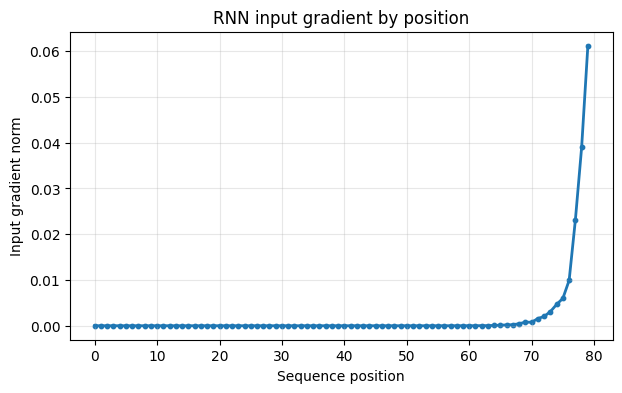

In [15]:
import matplotlib.pyplot as plt
# 实验第 4 步：RNN 的梯度分布
import torch
positions = torch.arange(seq_len)

plt.figure(figsize=(7, 4))
plt.plot(positions.numpy(), grad_by_pos.detach().numpy(), linewidth=2)
plt.scatter(positions.numpy(), grad_by_pos.detach().numpy(), s=10)
plt.xlabel("Sequence position")
plt.ylabel("Input gradient norm")
plt.title("RNN input gradient by position")
plt.grid(True, alpha=0.3)
plt.show()

near_end = grad_by_pos[-5:].mean().item()
far_start = grad_by_pos[:5].mean().item()
print("从图上对应的数值看：")
print(f"  前 5 个位置平均梯度: {far_start:.3e}")
print(f"  后 5 个位置平均梯度: {near_end:.3e}")
print()
print("观察：这次运行里，梯度主要集中在序列末尾附近。")
print("这就是 RNN 学长距离依赖时常见的困难：远处位置收到的学习信号很小。")


**实验第 5 步：序列变长会怎样？**

不改 RNN 的权重，只改序列长度。

先跑出曲线，再比较每条曲线最左边和最右边的数值。这张图使用 log 轴，log 轴上差一格，通常就是差很多倍。

从这次运行结果读数：
  seq_len=10: first=3.068e-04, last=9.274e-02, last/first≈3.023e+02
  seq_len=20: first=6.449e-08, last=5.034e-02, last/first≈7.806e+05
  seq_len=40: first=2.675e-11, last=9.605e-02, last/first≈3.591e+09
  seq_len=80: first=1.714e-19, last=6.119e-02, last/first≈3.570e+17

观察：序列越长，最早位置的梯度通常小到更多数量级。
结论：RNN 不是不能处理序列，而是长距离学习信号更难稳定传回去。
Attention 的核心动机就是：让远处 token 之间少走很多步。


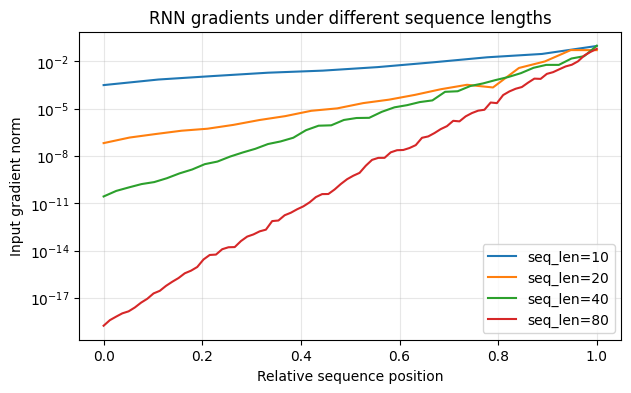

In [16]:
import matplotlib.pyplot as plt
# 实验第 5 步：不同序列长度下的梯度对比
import torch
import torch.nn as nn
def run_rnn_with_length(length):
    """使用同样配置的 nn.RNN，返回每个位置的输入梯度大小"""
    torch.manual_seed(42)
    model = nn.RNN(input_dim, hidden_dim, nonlinearity="tanh", batch_first=True)
    sample = torch.randn(batch_size, length, input_dim, requires_grad=True)
    out, _ = model(sample)
    loss = out[:, -1, :].pow(2).mean()
    loss.backward()
    return sample.grad.norm(dim=-1).squeeze(0).detach()

lengths = [10, 20, 40, 80]
length_results = {}

plt.figure(figsize=(7, 4))
for length in lengths:
    grads = run_rnn_with_length(length)
    length_results[length] = grads
    relative_pos = torch.linspace(0, 1, steps=length)
    plt.plot(relative_pos.numpy(), grads.numpy(), label=f"seq_len={length}")

plt.xlabel("Relative sequence position")
plt.ylabel("Input gradient norm")
plt.title("RNN gradients under different sequence lengths")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("从这次运行结果读数：")
for length in lengths:
    grads = length_results[length]
    first = grads[0].item()
    last = grads[-1].item()
    ratio = last / max(first, 1e-30)
    print(f"  seq_len={length:2d}: first={first:.3e}, last={last:.3e}, last/first≈{ratio:.3e}")

print()
print("观察：序列越长，最早位置的梯度通常小到更多数量级。")
print("结论：RNN 不是不能处理序列，而是长距离学习信号更难稳定传回去。")
print("Attention 的核心动机就是：让远处 token 之间少走很多步。")


**实验第 6 步：换成 PyTorch Attention 看梯度**

刚才 RNN 的问题是：最后一步的学习信号，要一步步传回开头。

Attention 会怎样？我们这次直接用 `torch.nn.MultiheadAttention`。还是同一个问题：只从最后一个位置反向传播，看前面位置能不能收到梯度。

这里使用 causal mask，所以最后一个位置可以看见前面所有位置，但前面位置不能看到未来。

In [17]:
# 实验第 6 步：用 PyTorch MultiheadAttention 观察输入梯度
import torch
import torch.nn as nn
torch.manual_seed(42)

attn_dim = 8
num_heads = 2
attention = nn.MultiheadAttention(
    embed_dim=attn_dim,
    num_heads=num_heads,
    batch_first=True,
)

attn_x = torch.randn(batch_size, seq_len, attn_dim, requires_grad=True)

# True 表示这个位置不能看。上三角 True，就是遮住未来。
attn_mask = torch.triu(torch.ones(seq_len, seq_len, dtype=torch.bool), diagonal=1)

attn_out, attn_weights = attention(
    attn_x,
    attn_x,
    attn_x,
    attn_mask=attn_mask,
    need_weights=True,
    average_attn_weights=False,
)

attn_loss = attn_out[:, -1, :].pow(2).mean()
attn_loss.backward()

attn_grad_by_pos = attn_x.grad.norm(dim=-1).squeeze(0).detach()
last_token_weights = attn_weights[0, :, -1, :].mean(dim=0).detach()

print("=== Gradients from last Attention output ===")
print(f"loss from last output: {attn_loss.item():.6f}")
print()
for pos in [0, 1, 5, 10, 20, 40, 60, 79]:
    grad = attn_grad_by_pos[pos].item()
    weight = last_token_weights[pos].item()
    print(f"position {pos:2d}: grad={grad:.10f}, attention_weight={weight:.10f}")

print()
print("从这次运行结果读数：")
print(f"  开头位置梯度: {attn_grad_by_pos[0].item():.3e}")
print(f"  中间位置梯度: {attn_grad_by_pos[seq_len // 2].item():.3e}")
print(f"  最后位置梯度: {attn_grad_by_pos[-1].item():.3e}")
print(f"  最后 token 的 attention weight 总和: {last_token_weights.sum().item():.3f}")
print()
print("观察：前面位置不再只能靠一步步传递，它们可以被最后一个位置直接看见。")


=== Gradients from last Attention output ===
loss from last output: 0.004143

position  0: grad=0.0004031110, attention_weight=0.0124237007
position  1: grad=0.0002321250, attention_weight=0.0076827370
position  5: grad=0.0002215537, attention_weight=0.0075380141
position 10: grad=0.0002874905, attention_weight=0.0104033612
position 20: grad=0.0002641352, attention_weight=0.0089868102
position 40: grad=0.0005811490, attention_weight=0.0123465005
position 60: grad=0.0003281604, attention_weight=0.0121112242
position 79: grad=0.0049361191, attention_weight=0.0140305962

从这次运行结果读数：
  开头位置梯度: 4.031e-04
  中间位置梯度: 5.811e-04
  最后位置梯度: 4.936e-03
  最后 token 的 attention weight 总和: 1.000

观察：前面位置不再只能靠一步步传递，它们可以被最后一个位置直接看见。


**把 RNN 和 Attention 放在同一张图里**

先看两条曲线，再读结论。

蓝线是 RNN：远处位置的梯度很容易贴近 0。

橙线是 Attention：前面位置的梯度通常仍然比最后位置小，但它们不是只能靠很多步传回去，而是通过 attention 权重直接连到最后位置。

从这张图读到的结论：
  RNN 的远处梯度更容易小到接近 0。
  Attention 的远处位置也可能梯度较小，但它们和最后位置之间有直接连接。
  这就是 Attention 更适合学习长距离关系的一个原因。


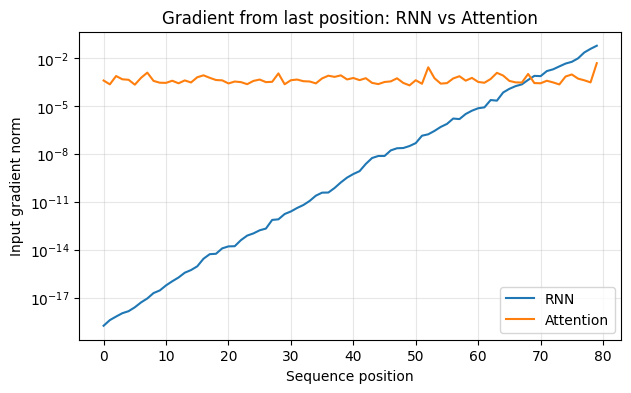

In [18]:
import matplotlib.pyplot as plt
# 对比：RNN 和 Attention 从最后位置反传回各输入位置的梯度
plt.figure(figsize=(7, 4))
plt.plot(positions.numpy(), grad_by_pos.detach().numpy(), label="RNN")
plt.plot(positions.numpy(), attn_grad_by_pos.numpy(), label="Attention")
plt.xlabel("Sequence position")
plt.ylabel("Input gradient norm")
plt.title("Gradient from last position: RNN vs Attention")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("从这张图读到的结论：")
print("  RNN 的远处梯度更容易小到接近 0。")
print("  Attention 的远处位置也可能梯度较小，但它们和最后位置之间有直接连接。")
print("  这就是 Attention 更适合学习长距离关系的一个原因。")


**最后一个 token 实际看向了哪里？**

Attention 不只给梯度，也给出最后一个位置对各位置的关注权重。

这些权重不是手填的，而是 `nn.MultiheadAttention` 在这次前向传播里算出来的。

从这张图读到的结论：
  最后一个 token 的 attention weight 分布在多个位置上。
  哪些位置权重大，哪些位置就更直接影响最后位置的输出。


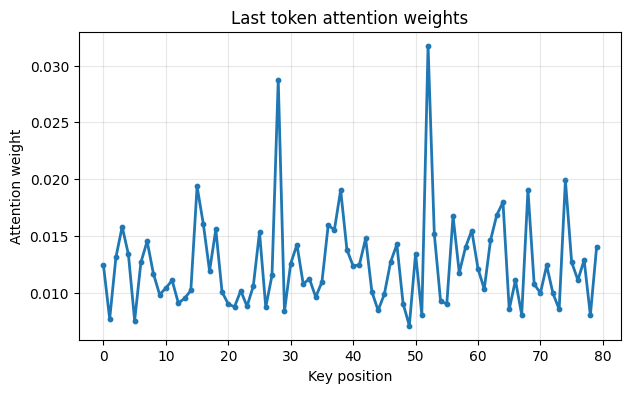

In [19]:
import matplotlib.pyplot as plt
# 最后一个 token 对整段序列的 attention weight
plt.figure(figsize=(7, 4))
plt.plot(positions.numpy(), last_token_weights.numpy(), linewidth=2)
plt.scatter(positions.numpy(), last_token_weights.numpy(), s=10)
plt.xlabel("Key position")
plt.ylabel("Attention weight")
plt.title("Last token attention weights")
plt.grid(True, alpha=0.3)
plt.show()

print("从这张图读到的结论：")
print("  最后一个 token 的 attention weight 分布在多个位置上。")
print("  哪些位置权重大，哪些位置就更直接影响最后位置的输出。")


**再看一个更有用的图：梯度累计分布**

前面的曲线告诉我们每个位置的梯度有多大。

但还有一个问题：如果把所有位置的梯度加起来，多少梯度集中在靠近结尾的位置？

下面画 cumulative gradient mass。曲线越晚才抬起来，说明梯度越集中在后面。

从累计分布读数：
  RNN 前半段拿到的梯度占比:       0.000%
  Attention 前半段拿到的梯度占比: 42.973%

观察：这次运行里，RNN 的梯度质量更集中在末尾。
Attention 仍然偏向末尾，但前半段也能拿到更可见的梯度占比。


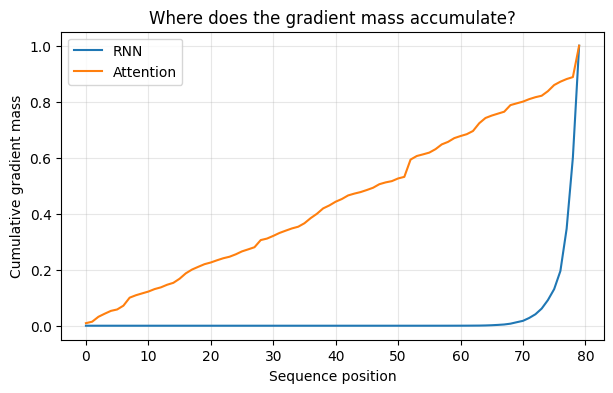

In [20]:
import matplotlib.pyplot as plt
# Insight 图：梯度累计分布
import torch
rnn_mass = grad_by_pos / grad_by_pos.sum()
attn_mass = attn_grad_by_pos / attn_grad_by_pos.sum()

rnn_cumsum = torch.cumsum(rnn_mass, dim=0)
attn_cumsum = torch.cumsum(attn_mass, dim=0)

plt.figure(figsize=(7, 4))
plt.plot(positions.numpy(), rnn_cumsum.numpy(), label="RNN")
plt.plot(positions.numpy(), attn_cumsum.numpy(), label="Attention")
plt.xlabel("Sequence position")
plt.ylabel("Cumulative gradient mass")
plt.title("Where does the gradient mass accumulate?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rnn_first_half = rnn_mass[:seq_len // 2].sum().item()
attn_first_half = attn_mass[:seq_len // 2].sum().item()

print("从累计分布读数：")
print(f"  RNN 前半段拿到的梯度占比:       {rnn_first_half:.3%}")
print(f"  Attention 前半段拿到的梯度占比: {attn_first_half:.3%}")
print()
print("观察：这次运行里，RNN 的梯度质量更集中在末尾。")
print("Attention 仍然偏向末尾，但前半段也能拿到更可见的梯度占比。")


**这组实验到底说明什么？**

请注意，这里不是说 Attention 的每个远处 token 梯度都会很大。更准确的说法是：

1. RNN 的远处信息要经过很多步传递，学习信号容易越来越弱。
2. Attention 让最后一个位置可以直接看前面所有位置，路径更短。
3. 实际梯度大小仍然取决于参数、输入和 attention weight。

所以后面才要研究 Q/K/V、mask 和 multi-head：它们决定了"直接看"具体怎么看。

## 作业

> 可以用 AI 询问思路、拆步骤、检查方向，但不建议直接让 AI "做完这道题"。

**作业 1：Attention score**

Attention 的第一步是用 query 和 key 算相关性分数。

**小提示**：两个向量点积可以用 `(q * k).sum()`。

In [ ]:
# 作业 1：Attention score 填空
import torch

q = torch.tensor([1.0, 2.0, 0.0])
k = torch.tensor([3.0, 1.0, 4.0])

# TODO：把下面三引号里的内容替换成你的代码
score = """在这里计算 q 和 k 的点积"""

assert not isinstance(score, str), "请先替换三引号里的占位内容"
assert score.item() == 5.0, score
print("✅ 作业 1 通过：你记住了 attention score 的核心是 QK 点积")


**作业 2：Causal mask**

GPT 生成时不能偷看未来 token，所以位置 `i` 只能看 `0...i`。

**小提示**：`torch.tril(torch.ones(seq_len, seq_len))` 会生成下三角矩阵。

In [ ]:
# 作业 2：Causal Mask 填空
import torch

seq_len = 5

# TODO：生成一个 5x5 的下三角 causal mask
mask = """在这里生成 causal mask"""

expected = torch.tensor([
    [1, 0, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [1, 1, 1, 0, 0],
    [1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
])
assert not isinstance(mask, str), "请先替换三引号里的占位内容"
assert torch.equal(mask, expected), mask
print("✅ 作业 2 通过：你理解了 GPT 为什么只能看过去")


**作业 3：FFN 的参数量计算**Transformer 中的 Feed-Forward Network（FFN）由两个线性层组成。假设 hidden_size = 512，FFN 的中间维度 d_ff = 2048。计算 FFN 的总参数量（包含偏置）。小提示：W1 是 2048x512 + 2048 偏置；W2 是 512x2048 + 512 偏置。

In [21]:
# 作业 3：FFN 参数量计算hidden_size = 512d_ff = 2048# TODO: 计算 W1 的参数量（包含偏置）w1_params = None  # d_ff * hidden_size + d_ff# TODO: 计算 W2 的参数量（包含偏置）w2_params = None  # hidden_size * d_ff + hidden_size# TODO: 计算 FFN 总参数量total_params = Noneassert w1_params is not Noneassert w2_params is not Noneassert total_params is not Noneexpected_w1 = d_ff * hidden_size + d_ffexpected_w2 = hidden_size * d_ff + hidden_sizeexpected_total = expected_w1 + expected_w2assert w1_params == expected_w1, f'W1 参数应为 {expected_w1}'assert w2_params == expected_w2, f'W2 参数应为 {expected_w2}'assert total_params == expected_total, f'总参数应为 {expected_total}'print(f'W1: {w1_params:,} 参数')print(f'W2: {w2_params:,} 参数')print(f'FFN 总计: {total_params:,} 参数')print(f'FFN 参数量约是 hidden_size^2 的 {total_params / (hidden_size**2):.0f} 倍')print('FFN 通常占 Transformer Block 参数量的 2/3 左右。')print(chr(10004) + ' 作业 3 通过')

## 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — Transformer 原始论文，Scaled Dot-Product Attention 和 Multi-Head Attention 的定义均来自此文
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — 对原始论文的逐行实现与注释，本文缩放因子 √d_k 的方差论证参考了该文的推导
- Karpathy, [Let's build GPT: from scratch, in code, spelled out](https://www.youtube.com/watch?v=kCc8FmEb1nY) — 视频教程，用代码从零实现 GPT